In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import datasets, transforms, models
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.segmentation import deeplabv3_resnet50

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import json
import pandas as pd
from collections import defaultdict
import random

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
transform_base = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_aug = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
stl10_train = datasets.STL10(root='./data', split='train', download=True, transform=transform_base)
stl10_test = datasets.STL10(root='./data', split='test', download=True, transform=transform_base)

In [5]:
train_size = int(0.8 * len(stl10_train))
val_size = len(stl10_train) - train_size
train_dataset, val_dataset = random_split(stl10_train, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

In [6]:
datasets_c1 = {
    'train': train_dataset, 
    'val': val_dataset,
    'test': stl10_test
}

train_indices = list(range(train_size))
train_c2 = Subset(stl10_train, train_indices)
train_c2.dataset.transform = transform_aug
val_c2 = val_dataset
test_c2 = stl10_test
datasets_c2 = {
    'train': train_c2,
    'val': val_c2,
    'test': test_c2
}

stl10_train_resnet = datasets.STL10(root='./data', split='train', download=True, transform=transform_resnet)
stl10_test_resnet = datasets.STL10(root='./data', split='test', download=True, transform=transform_resnet)
train_resnet, val_resnet = random_split(stl10_train_resnet, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))
datasets_c3 = {
    'train': train_resnet,
    'val': val_resnet,
    'test': stl10_test_resnet
}
datasets_c4 = datasets_c3

In [7]:
BATCH_SIZE = 64
NUM_WORKERS = 2
def get_loaders(datasets_dict):
    return {
        'train': DataLoader(datasets_dict['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
        'val': DataLoader(datasets_dict['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
        'test': DataLoader(datasets_dict['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    }

loaders_c1 = get_loaders(datasets_c1)
loaders_c2 = get_loaders(datasets_c2)
loaders_c3 = get_loaders(datasets_c3)
loaders_c4 = get_loaders(datasets_c4)

In [8]:
for name, loader in loaders_c1.items():
    x, y = next(iter(loader))
    print(f'{name}: x.shape={x.shape}, y.shape={y.shape}')

train: x.shape=torch.Size([64, 3, 96, 96]), y.shape=torch.Size([64])
val: x.shape=torch.Size([64, 3, 96, 96]), y.shape=torch.Size([64])
test: x.shape=torch.Size([64, 3, 96, 96]), y.shape=torch.Size([64])


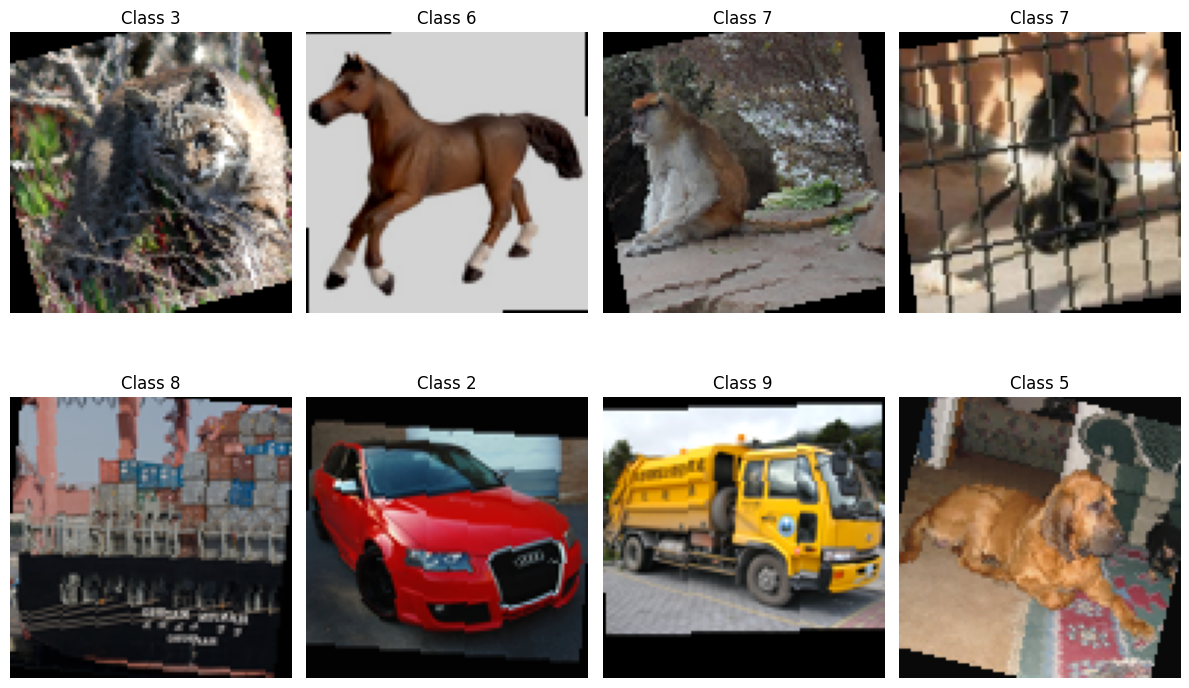

In [9]:
def imshow(img, title=None):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

dataiter = iter(loaders_c1['train'])
images, labels = next(dataiter)
plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(images[i])
    plt.title(f'Class {labels[i].item()}')
plt.tight_layout()
plt.savefig('artifacts/figures/classification_samples.png')
plt.show()

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(256, num_classes)
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model_cnn = SimpleCNN(num_classes=10).to(device)
print(model_cnn)

SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (fc): Linear(in_features=256, out_features=10, bias=True)
)


In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, epochs, lr, device, model_name='model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
    model.load_state_dict(best_model_state)
    return model, history, best_val_acc

In [12]:
EPOCHS = 20
LR = 0.001

model_c1 = SimpleCNN(num_classes=10).to(device)
print("Training C1: SimpleCNN base")
model_c1, history_c1, best_val_acc_c1 = train_model(model_c1, loaders_c1['train'], loaders_c1['val'], EPOCHS, LR, device, 'C1')
print(f"Best val accuracy: {best_val_acc_c1:.4f}")

histories = {'C1': history_c1}
best_vals = {'C1': best_val_acc_c1}

Training C1: SimpleCNN base
Epoch 1/20 | Train Loss: 2.1324 Acc: 0.1847 | Val Loss: 1.9963 Acc: 0.2660
Epoch 2/20 | Train Loss: 1.9024 Acc: 0.2565 | Val Loss: 1.9013 Acc: 0.2770
Epoch 3/20 | Train Loss: 1.7703 Acc: 0.2995 | Val Loss: 1.7722 Acc: 0.2780
Epoch 4/20 | Train Loss: 1.7199 Acc: 0.3222 | Val Loss: 1.6361 Acc: 0.3680
Epoch 5/20 | Train Loss: 1.6416 Acc: 0.3463 | Val Loss: 1.5947 Acc: 0.3550
Epoch 6/20 | Train Loss: 1.6099 Acc: 0.3700 | Val Loss: 1.6640 Acc: 0.3200
Epoch 7/20 | Train Loss: 1.5900 Acc: 0.3648 | Val Loss: 1.5989 Acc: 0.3900
Epoch 8/20 | Train Loss: 1.5554 Acc: 0.3802 | Val Loss: 1.5303 Acc: 0.3980
Epoch 9/20 | Train Loss: 1.5497 Acc: 0.3905 | Val Loss: 1.5134 Acc: 0.4160
Epoch 10/20 | Train Loss: 1.5396 Acc: 0.4050 | Val Loss: 1.5186 Acc: 0.3880
Epoch 11/20 | Train Loss: 1.5020 Acc: 0.4215 | Val Loss: 1.4763 Acc: 0.4370
Epoch 12/20 | Train Loss: 1.4572 Acc: 0.4377 | Val Loss: 1.4771 Acc: 0.4180
Epoch 13/20 | Train Loss: 1.4545 Acc: 0.4405 | Val Loss: 1.4452 Acc: 

In [13]:
model_c2 = SimpleCNN(num_classes=10).to(device)
print("Training C2: SimpleCNN with augmentations")
model_c2, history_c2, best_val_acc_c2 = train_model(model_c2, loaders_c2['train'], loaders_c2['val'], EPOCHS, LR, device, 'C2')
print(f"Best val accuracy: {best_val_acc_c2:.4f}")
histories['C2'] = history_c2
best_vals['C2'] = best_val_acc_c2

Training C2: SimpleCNN with augmentations
Epoch 1/20 | Train Loss: 2.1579 Acc: 0.1870 | Val Loss: 2.0504 Acc: 0.2240
Epoch 2/20 | Train Loss: 1.9553 Acc: 0.2525 | Val Loss: 1.8668 Acc: 0.2960
Epoch 3/20 | Train Loss: 1.7866 Acc: 0.2935 | Val Loss: 1.7828 Acc: 0.3040
Epoch 4/20 | Train Loss: 1.7161 Acc: 0.3242 | Val Loss: 1.6189 Acc: 0.3520
Epoch 5/20 | Train Loss: 1.6821 Acc: 0.3395 | Val Loss: 1.6122 Acc: 0.3650
Epoch 6/20 | Train Loss: 1.6354 Acc: 0.3565 | Val Loss: 1.5496 Acc: 0.3770
Epoch 7/20 | Train Loss: 1.6009 Acc: 0.3728 | Val Loss: 1.6135 Acc: 0.3640
Epoch 8/20 | Train Loss: 1.6095 Acc: 0.3748 | Val Loss: 1.5672 Acc: 0.3860
Epoch 9/20 | Train Loss: 1.5630 Acc: 0.3802 | Val Loss: 1.5105 Acc: 0.4130
Epoch 10/20 | Train Loss: 1.5399 Acc: 0.4000 | Val Loss: 1.4774 Acc: 0.4220
Epoch 11/20 | Train Loss: 1.5058 Acc: 0.4100 | Val Loss: 1.4417 Acc: 0.4500
Epoch 12/20 | Train Loss: 1.4891 Acc: 0.4198 | Val Loss: 1.4290 Acc: 0.4540
Epoch 13/20 | Train Loss: 1.4733 Acc: 0.4417 | Val Loss

In [14]:
num_classes = 10
model_c3 = models.resnet18(weights='IMAGENET1K_V1')
for param in model_c3.parameters():
    param.requires_grad = False
model_c3.fc = nn.Linear(model_c3.fc.in_features, num_classes)
model_c3 = model_c3.to(device)

print("Training C3: ResNet18 head only")
model_c3, history_c3, best_val_acc_c3 = train_model(model_c3, loaders_c3['train'], loaders_c3['val'], EPOCHS, LR, device, 'C3')
print(f"Best val accuracy: {best_val_acc_c3:.4f}")
histories['C3'] = history_c3
best_vals['C3'] = best_val_acc_c3

Training C3: ResNet18 head only
Epoch 1/20 | Train Loss: 1.1142 Acc: 0.7198 | Val Loss: 0.4530 Acc: 0.9160
Epoch 2/20 | Train Loss: 0.3588 Acc: 0.9295 | Val Loss: 0.2924 Acc: 0.9350
Epoch 3/20 | Train Loss: 0.2573 Acc: 0.9383 | Val Loss: 0.2454 Acc: 0.9320
Epoch 4/20 | Train Loss: 0.2129 Acc: 0.9460 | Val Loss: 0.2285 Acc: 0.9430
Epoch 5/20 | Train Loss: 0.1829 Acc: 0.9533 | Val Loss: 0.2093 Acc: 0.9430
Epoch 6/20 | Train Loss: 0.1667 Acc: 0.9545 | Val Loss: 0.1909 Acc: 0.9450
Epoch 7/20 | Train Loss: 0.1522 Acc: 0.9597 | Val Loss: 0.1886 Acc: 0.9470
Epoch 8/20 | Train Loss: 0.1408 Acc: 0.9633 | Val Loss: 0.1834 Acc: 0.9410
Epoch 9/20 | Train Loss: 0.1264 Acc: 0.9643 | Val Loss: 0.1806 Acc: 0.9450
Epoch 10/20 | Train Loss: 0.1211 Acc: 0.9677 | Val Loss: 0.1780 Acc: 0.9400
Epoch 11/20 | Train Loss: 0.1136 Acc: 0.9683 | Val Loss: 0.1719 Acc: 0.9510
Epoch 12/20 | Train Loss: 0.1061 Acc: 0.9730 | Val Loss: 0.1764 Acc: 0.9430
Epoch 13/20 | Train Loss: 0.1023 Acc: 0.9728 | Val Loss: 0.1765 A

In [15]:
model_c4 = models.resnet18(weights='IMAGENET1K_V1')
for name, param in model_c4.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
model_c4.fc = nn.Linear(model_c4.fc.in_features, num_classes)
model_c4 = model_c4.to(device)

print("Training C4: ResNet18 fine-tune (layer4+fc)")
model_c4, history_c4, best_val_acc_c4 = train_model(model_c4, loaders_c4['train'], loaders_c4['val'], EPOCHS, LR, device, 'C4')
print(f"Best val accuracy: {best_val_acc_c4:.4f}")
histories['C4'] = history_c4
best_vals['C4'] = best_val_acc_c4

Training C4: ResNet18 fine-tune (layer4+fc)
Epoch 1/20 | Train Loss: 0.3937 Acc: 0.8728 | Val Loss: 0.3897 Acc: 0.8790
Epoch 2/20 | Train Loss: 0.0870 Acc: 0.9710 | Val Loss: 0.2678 Acc: 0.9190
Epoch 3/20 | Train Loss: 0.0392 Acc: 0.9888 | Val Loss: 0.2456 Acc: 0.9320
Epoch 4/20 | Train Loss: 0.0154 Acc: 0.9960 | Val Loss: 0.2790 Acc: 0.9220
Epoch 5/20 | Train Loss: 0.0298 Acc: 0.9910 | Val Loss: 0.3376 Acc: 0.9040
Epoch 6/20 | Train Loss: 0.0531 Acc: 0.9838 | Val Loss: 0.3998 Acc: 0.8980
Epoch 7/20 | Train Loss: 0.0569 Acc: 0.9830 | Val Loss: 0.4085 Acc: 0.8860
Epoch 8/20 | Train Loss: 0.0317 Acc: 0.9898 | Val Loss: 0.3681 Acc: 0.9030
Epoch 9/20 | Train Loss: 0.0223 Acc: 0.9940 | Val Loss: 0.2790 Acc: 0.9150
Epoch 10/20 | Train Loss: 0.0152 Acc: 0.9955 | Val Loss: 0.3917 Acc: 0.9080
Epoch 11/20 | Train Loss: 0.0298 Acc: 0.9918 | Val Loss: 0.3470 Acc: 0.9100
Epoch 12/20 | Train Loss: 0.0162 Acc: 0.9945 | Val Loss: 0.3202 Acc: 0.9120
Epoch 13/20 | Train Loss: 0.0099 Acc: 0.9968 | Val Lo

In [16]:
experiments = ['C1', 'C2', 'C3', 'C4']
best_exp = max(experiments, key=lambda x: best_vals[x])
print(f"Best experiment: {best_exp} with val accuracy {best_vals[best_exp]:.4f}")

if best_exp == 'C1':
    best_model = model_c1
    test_loader = loaders_c1['test']
elif best_exp == 'C2':
    best_model = model_c2
    test_loader = loaders_c2['test']
elif best_exp == 'C3':
    best_model = model_c3
    test_loader = loaders_c3['test']
else:
    best_model = model_c4
    test_loader = loaders_c4['test']

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Test accuracy of best model ({best_exp}): {test_acc:.4f}")
best_model.eval()
with torch.no_grad():
    inputs, labels = next(iter(test_loader))
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = best_model(inputs)
    preds = torch.argmax(outputs, dim=1)
    print("Sample predictions:", preds[:10])
    print("Sample true labels:", labels[:10])

Best experiment: C3 with val accuracy 0.9510
Test accuracy of best model (C3): 0.9454
Sample predictions: tensor([6, 7, 5, 0, 3, 1, 1, 1, 4, 4])
Sample true labels: tensor([6, 7, 5, 0, 3, 1, 1, 1, 4, 4])


In [17]:
torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')

config = {
    'dataset': 'STL10',
    'architecture': best_exp,
    'transforms': 'augmented' if best_exp == 'C2' else ('base' if best_exp == 'C1' else 'resnet'),
    'seed': SEED,
    'epochs': EPOCHS,
    'lr': LR,
    'batch_size': BATCH_SIZE,
    'best_val_accuracy': best_vals[best_exp],
    'test_accuracy': test_acc
}
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)

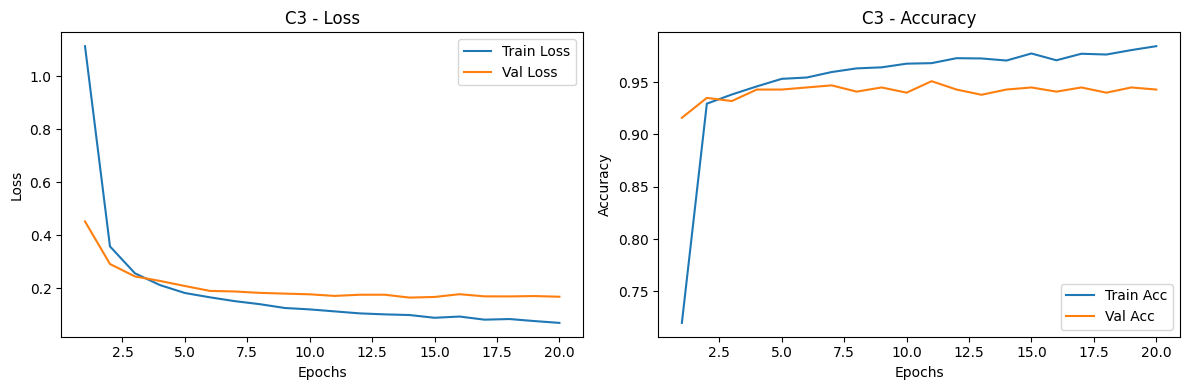

In [18]:
def plot_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{title} - Loss')
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{title} - Accuracy')
    plt.tight_layout()
    plt.savefig(f'artifacts/figures/classification_curves_{title.lower()}.png')
    plt.show()

plot_history(histories[best_exp], best_exp)

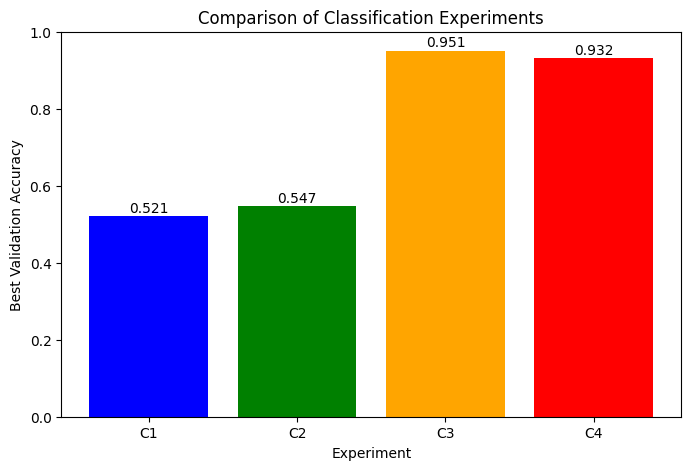

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(experiments, [best_vals[e] for e in experiments], color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Experiment')
plt.ylabel('Best Validation Accuracy')
plt.title('Comparison of Classification Experiments')
for i, v in enumerate([best_vals[e] for e in experiments]):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.ylim(0, 1)
plt.savefig('artifacts/figures/classification_compare.png')
plt.show()

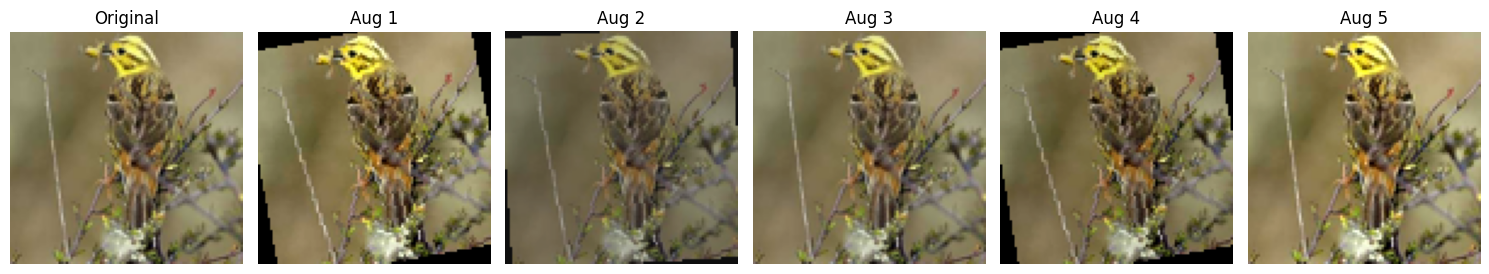

In [21]:
stl10_raw = datasets.STL10(root='./data', split='train', download=True, transform=None)
sample_raw_img, _ = stl10_raw[0]

def show_augmentations(original_pil, transform, num_aug=5):
    fig, axes = plt.subplots(1, num_aug+1, figsize=(15, 3))
    axes[0].imshow(original_pil)
    axes[0].set_title("Original")
    axes[0].axis('off')
    for i in range(num_aug):
        aug_img = transform(original_pil) 
        aug_img_disp = aug_img / 2 + 0.5
        axes[i+1].imshow(aug_img_disp.permute(1,2,0).numpy())
        axes[i+1].set_title(f"Aug {i+1}")
        axes[i+1].axis('off')
    plt.tight_layout()
    plt.savefig('artifacts/figures/augmentations_preview.png')
    plt.show()

show_augmentations(sample_raw_img, transform_aug)

In [22]:
from torchvision.datasets import VOCDetection
from torchvision.transforms import functional as F
import torchvision.transforms as T

voc_test = VOCDetection(root='./data', year='2007', image_set='test', download=True)
transform_voc = T.Compose([T.ToTensor()])

indices = [0, 1, 2]
images = [voc_test[i][0] for i in indices]
targets = [voc_test[i][1] for i in indices]

model_det = fasterrcnn_resnet50_fpn(pretrained=True)
model_det.eval()
model_det.to(device)

100%|██████████| 451M/451M [06:43<00:00, 1.12MB/s] 
/opt/homebrew/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [23]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1)
    area1 = (box1[2] - box1[0] + 1) * (box1[3] - box1[1] + 1)
    area2 = (box2[2] - box2[0] + 1) * (box2[3] - box2[1] + 1)
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

def evaluate_detection(model, images, targets, score_threshold=0.5, iou_threshold=0.5):
    model.eval()
    all_tp = 0
    all_fp = 0
    all_fn = 0
    total_iou = 0
    matched = 0
    with torch.no_grad():
        for img, target in zip(images, targets):
            img_tensor = transform_voc(img).unsqueeze(0).to(device)
            preds = model(img_tensor)[0]
            keep = preds['scores'] >= score_threshold
            pred_boxes = preds['boxes'][keep].cpu().numpy()
            pred_labels = preds['labels'][keep].cpu().numpy()
            gt_boxes = []
            for obj in target['annotation']['object']:
                bndbox = obj['bndbox']
                gt_boxes.append([
                    int(bndbox['xmin']), int(bndbox['ymin']),
                    int(bndbox['xmax']), int(bndbox['ymax'])
                ])
            gt_boxes = np.array(gt_boxes)
            if len(gt_boxes) == 0:
                all_fp += len(pred_boxes)
                continue
            matched_gt = set()
            for i, pbox in enumerate(pred_boxes):
                best_iou = 0
                best_j = -1
                for j, gbox in enumerate(gt_boxes):
                    if j in matched_gt:
                        continue
                    iou = compute_iou(pbox, gbox)
                    if iou > best_iou:
                        best_iou = iou
                        best_j = j
                if best_iou >= iou_threshold:
                    all_tp += 1
                    matched_gt.add(best_j)
                    total_iou += best_iou
                    matched += 1
                else:
                    all_fp += 1
            all_fn += len(gt_boxes) - len(matched_gt)
    precision = all_tp / (all_tp + all_fp) if (all_tp + all_fp) > 0 else 0
    recall = all_tp / (all_tp + all_fn) if (all_tp + all_fn) > 0 else 0
    mean_iou = total_iou / matched if matched > 0 else 0
    return precision, recall, mean_iou

thresholds = [0.3, 0.7]
results_det = []
for th in thresholds:
    p, r, miou = evaluate_detection(model_det, images, targets, score_threshold=th)
    results_det.append({'threshold': th, 'precision': p, 'recall': r, 'mean_iou': miou})
    print(f"Threshold {th}: Precision={p:.4f}, Recall={r:.4f}, mIoU={miou:.4f}")

Threshold 0.3: Precision=0.4444, Recall=0.8000, mIoU=0.8553
Threshold 0.7: Precision=0.7500, Recall=0.6000, mIoU=0.8796


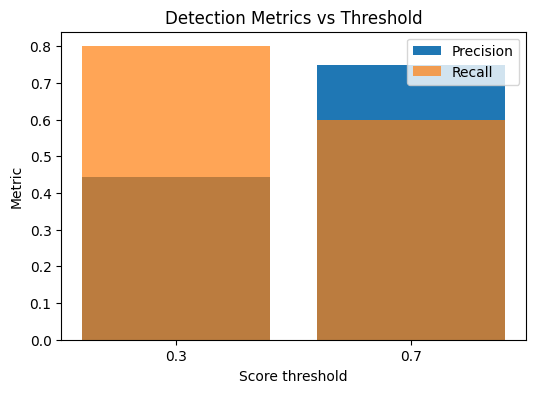

In [24]:
plt.figure(figsize=(6,4))
plt.bar([str(th) for th in thresholds], [r['precision'] for r in results_det], label='Precision')
plt.bar([str(th) for th in thresholds], [r['recall'] for r in results_det], alpha=0.7, label='Recall')
plt.xlabel('Score threshold')
plt.ylabel('Metric')
plt.legend()
plt.title('Detection Metrics vs Threshold')
plt.savefig('artifacts/figures/detection_metrics.png')
plt.show()

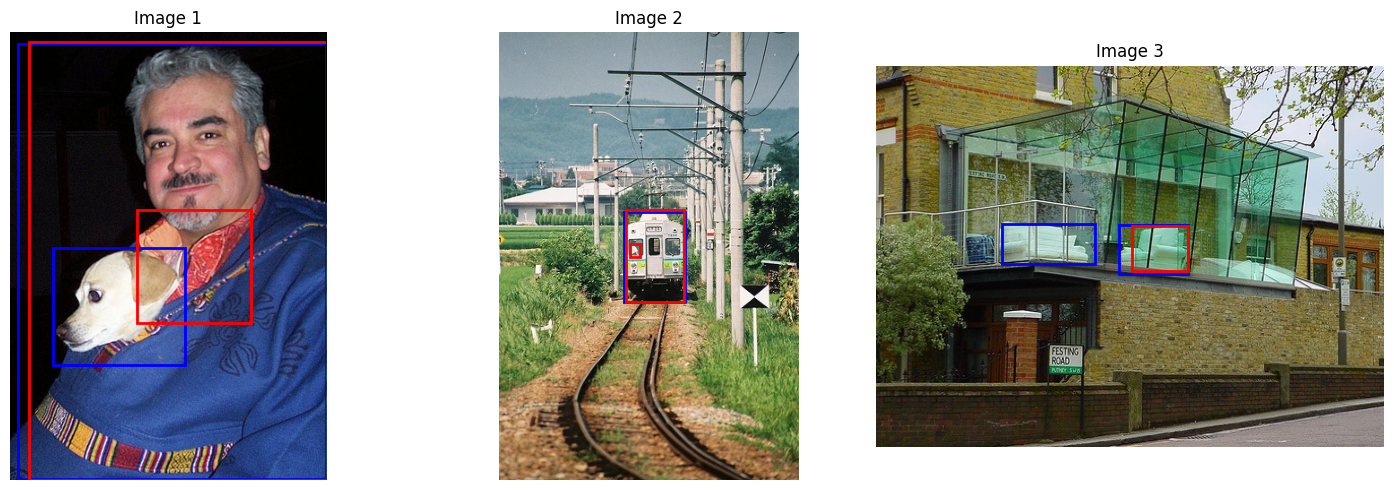

In [25]:
def visualize_detections(model, images, targets, score_threshold=0.5):
    model.eval()
    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
    if len(images) == 1:
        axes = [axes]
    for idx, (img, target) in enumerate(zip(images, targets)):
        img_tensor = transform_voc(img).unsqueeze(0).to(device)
        with torch.no_grad():
            preds = model(img_tensor)[0]
        keep = preds['scores'] >= score_threshold
        pred_boxes = preds['boxes'][keep].cpu().numpy()
        img_np = np.array(img)
        axes[idx].imshow(img_np)
        for obj in target['annotation']['object']:
            bndbox = obj['bndbox']
            xmin, ymin, xmax, ymax = int(bndbox['xmin']), int(bndbox['ymin']), int(bndbox['xmax']), int(bndbox['ymax'])
            rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=2, edgecolor='blue', facecolor='none')
            axes[idx].add_patch(rect)
        for box in pred_boxes:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=2, edgecolor='red', facecolor='none')
            axes[idx].add_patch(rect)
        axes[idx].axis('off')
        axes[idx].set_title(f"Image {idx+1}")
    plt.tight_layout()
    plt.savefig('artifacts/figures/detection_examples.png')
    plt.show()

visualize_detections(model_det, images, targets, score_threshold=0.5)

In [26]:
runs = []

# Классификация
for exp_id in experiments:
    best_val = best_vals[exp_id]
    runs.append({
        'experiment_id': exp_id,
        'task': 'classification',
        'dataset': 'STL10',
        'seed': SEED,
        'model_summary': str(eval(f"model_{exp_id.lower()}")),
        'optimizer': 'Adam',
        'lr': LR,
        'epochs_trained': EPOCHS,
        'best_val_accuracy': best_val,
        'test_accuracy': test_acc if exp_id == best_exp else None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': ''
    })

# Детекция
for res in results_det:
    runs.append({
        'experiment_id': f"V{1 if res['threshold']==0.3 else 2}",
        'task': 'detection',
        'dataset': 'VOC2007',
        'seed': SEED,
        'model_summary': 'fasterrcnn_resnet50_fpn',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': res['precision'],
        'recall': res['recall'],
        'mean_iou': res['mean_iou'],
        'notes': f"score_threshold={res['threshold']}"
    })

df_runs = pd.DataFrame(runs)
df_runs.to_csv('artifacts/runs.csv', index=False)
print("runs.csv saved")

runs.csv saved
